# Exercicio 3
## Parte 1 - Classificação

### Instalar pacotes

In [ ]:
!python3 -m pip install -r ../requirements.txt

### Importar pacotes e ler dataframe

In [74]:
import pandas as pd
from sklearn import tree
df = pd.read_csv('../data/titanic.csv')
df

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


### Transforma a coluna 'Sex' em categórica e gera códigos numéricos

In [76]:
df['Sex'] = pd.Categorical(df['Sex'])
df['sex_code'] = df['Sex'].cat.codes
df

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,sex_code
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,1
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,0
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,0
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,0
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,1
...,...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000,1
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000,0
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500,0
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000,1


### 1 - Divide o dataframe em treino e teste

In [77]:
from sklearn.model_selection import train_test_split

X = df[["Pclass", "sex_code", "Age", "Siblings/Spouses Aboard", "Parents/Children Aboard", "Fare"]]
y = df["Survived"]

# o random_state = 10 é utilizado para ter resultados consistentes durante os testes
df_train, df_test = train_test_split(df, test_size=0.7, random_state=10)

X_train = df_train[["Pclass", "sex_code", "Age", "Siblings/Spouses Aboard", "Parents/Children Aboard", "Fare"]]
y_train = df_train["Survived"]

#### 1.a - Árvore de decisão:

[]

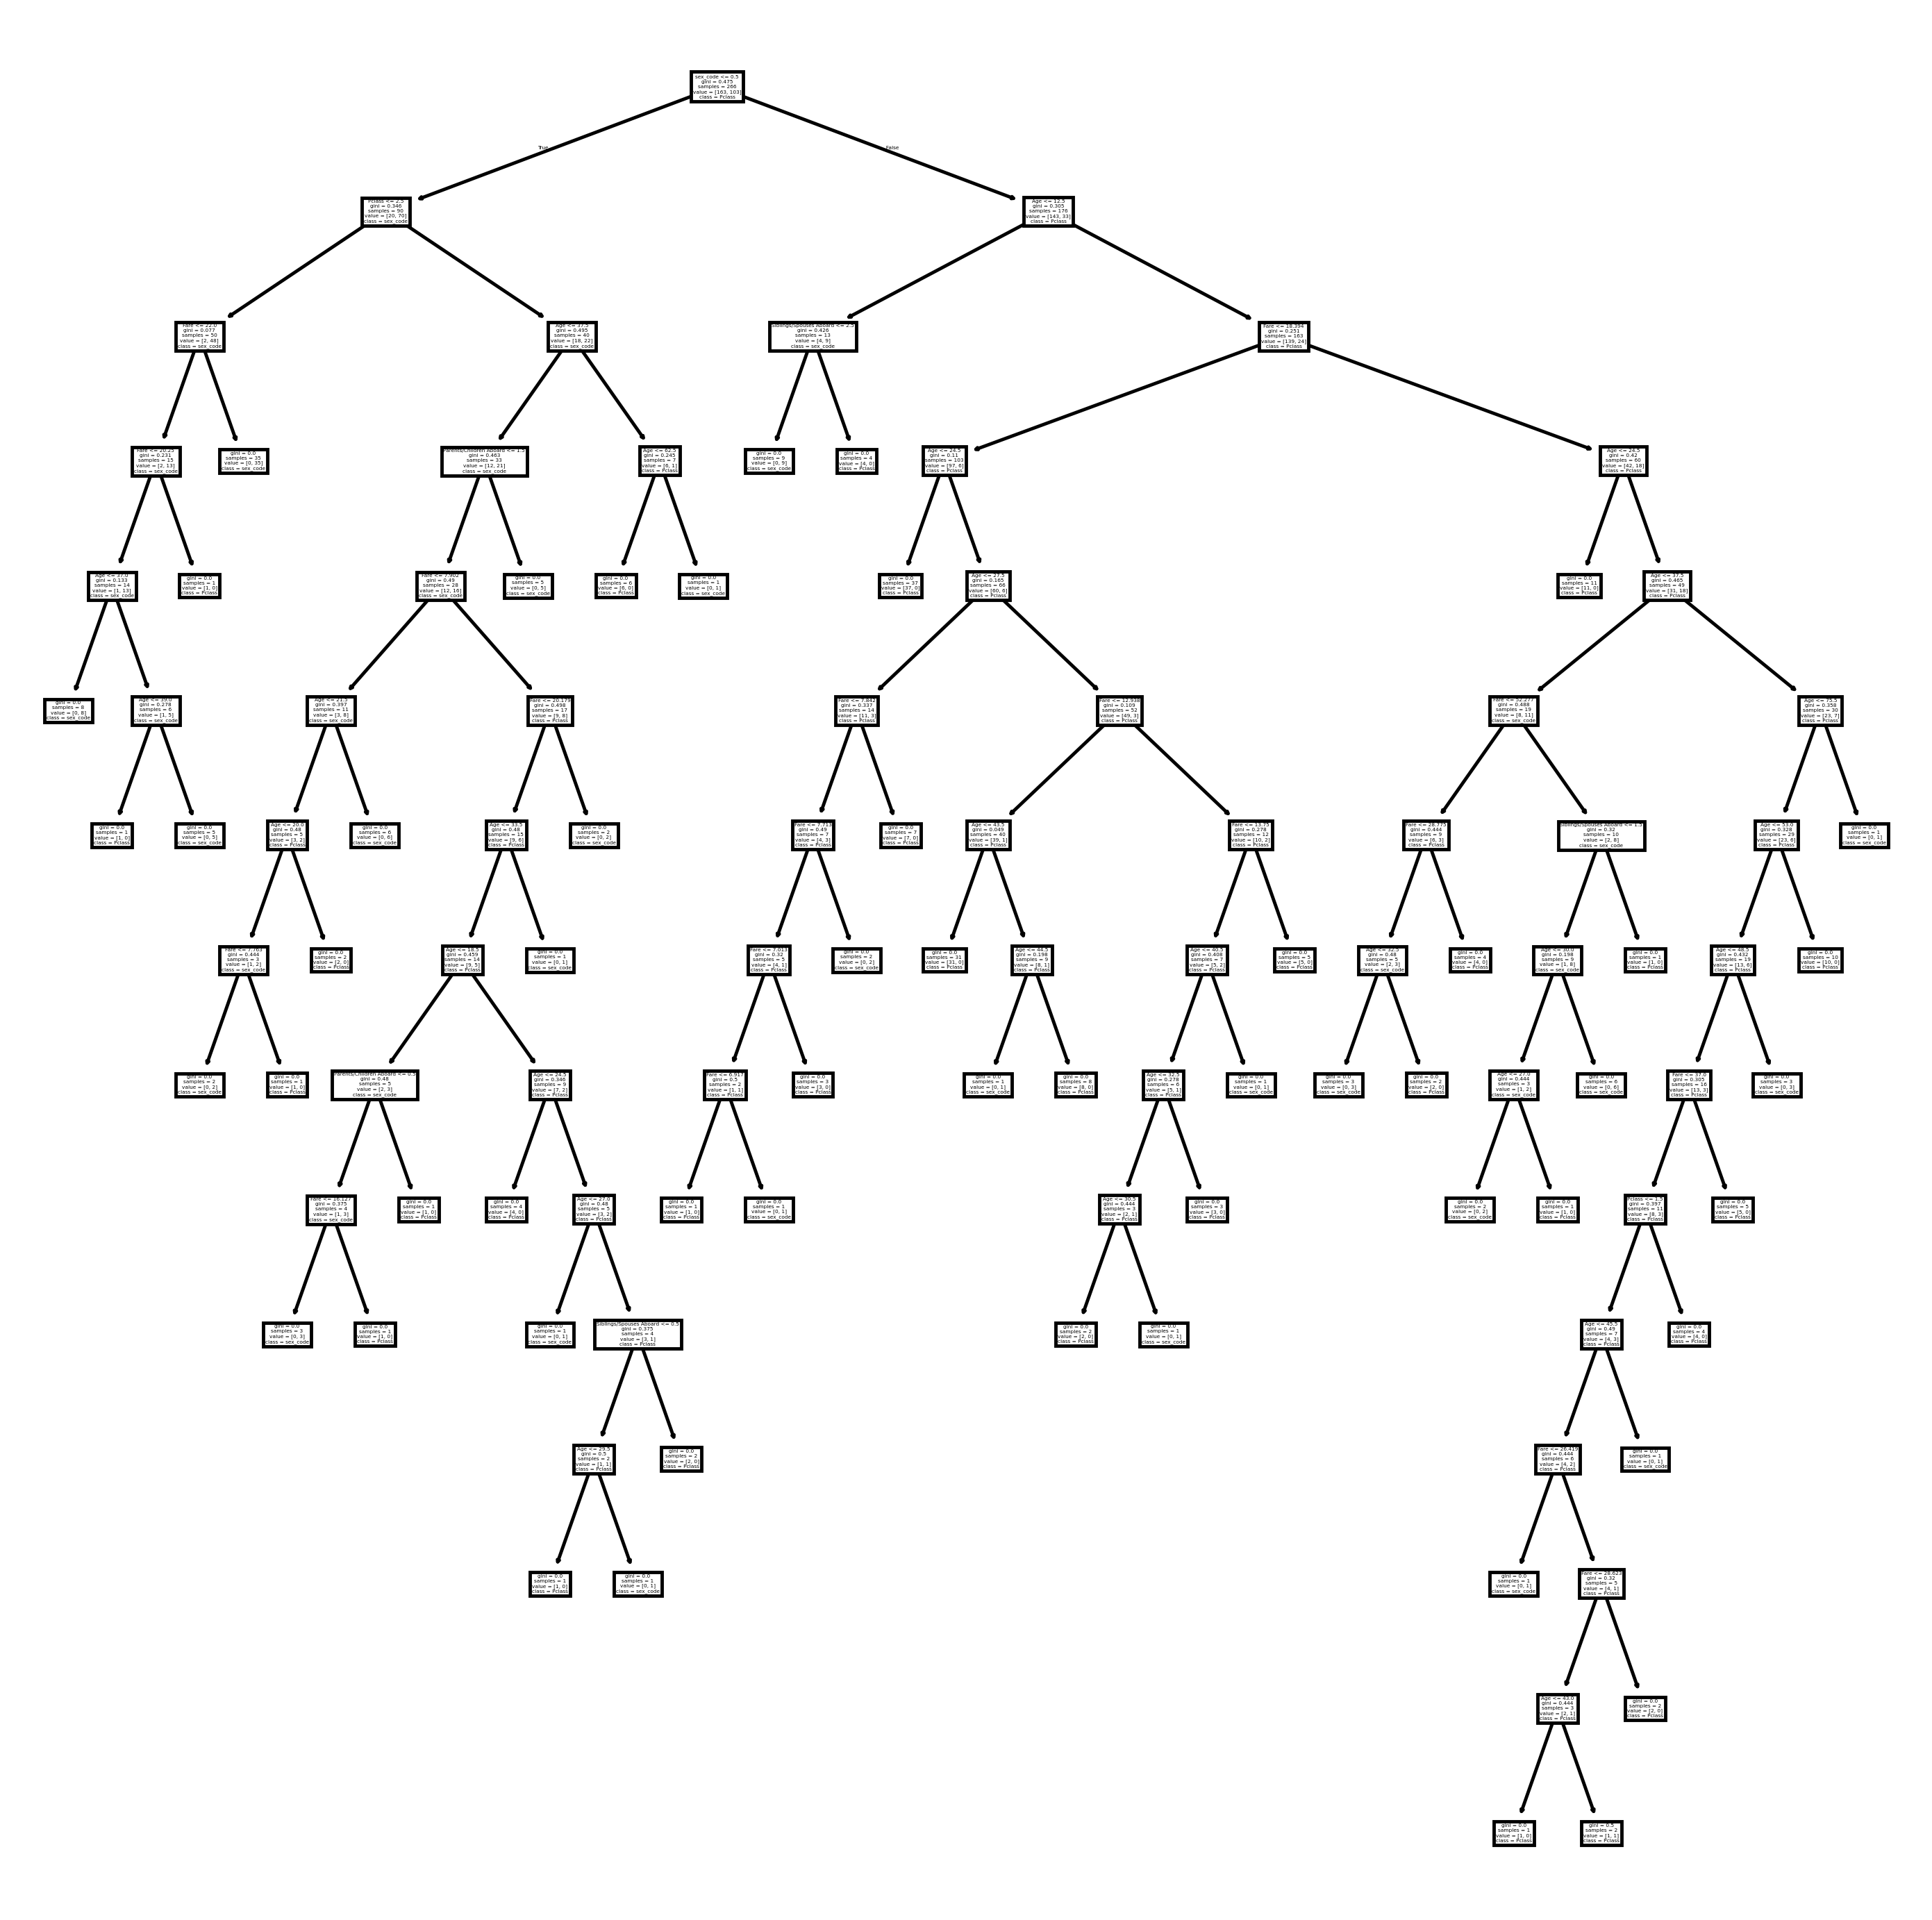

In [78]:
import matplotlib.pyplot as plt

tree_model = tree.DecisionTreeClassifier()

tree_model.fit(X_train, y_train)

fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (10,10), dpi=350)
tree.plot_tree(tree_model, feature_names = X_train.columns, class_names=["Pclass", "sex_code", "Age", "Siblings/Spouses Aboard", "Parents/Children Aboard", "Fare"])
plt.plot()

#### 1.b - Acurácia do modelo

In [81]:
X_test = df_test[["Pclass", "sex_code", "Age", "Siblings/Spouses Aboard", "Parents/Children Aboard", "Fare"]]
y_test = df_test["Survived"]

tree_model.score(X_test, y_test)

0.7600644122383253

### 2 - Avaliação k-fold

In [86]:
from sklearn.model_selection import cross_val_score

tree_2 = tree.DecisionTreeClassifier()
scores = cross_val_score(tree_2, X, y, cv=10)

print(scores)
print(scores.std())
print(scores.mean())

[0.73033708 0.75280899 0.74157303 0.76404494 0.84269663 0.79775281
 0.80898876 0.80681818 0.80681818 0.84090909]
0.03783049547293254
0.7892747701736466


Ao dividir o dataset em 10 subconjuntos com a validação 10-fold, a acurácia média é similar a obtida anteriormente, de 76%. Isso indica que o dataset é balanceado e que mesmo utilizando diferentes subconjuntos, os resultados continuam consistentes com uma amostragem aleatória do dataset completo. Também é possível afirmar que não existe overfitting ou underfitting em nenhum subconjunto específico.

### 4 - k-NN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import statistics

nn_scores = []

for i in range(2, 8):
    neighbors = KNeighborsClassifier(n_neighbors=i)
    scores = cross_val_score(neighbors, X, y, cv=10)
    nn_scores.append(scores.mean())
    print(i, ":", scores.mean())

print("desvio padrao: ", statistics.stdev(nn_scores))

2 : 0.7001149131767109
3 : 0.7148493360572014
4 : 0.7002170582226762
5 : 0.706958631256384
6 : 0.7069203268641472
7 : 0.6946373850868233
desvio padrao:  0.007099827759331275


Utilizando a técnica k-NN para previsão de sobrevivência com múltiplos valores de nearest neighbors (NN) e validação 10-fold, observa-se que não existe nenhum número de NN resulta em uma acurácia maior do que o modelo de árvore de decisão e que todos obtiveram uma performance similar, com um desvio padrão pequeno.

## Parte 2 - Agrupamento

In [24]:
df_toronto = pd.read_csv("../desafio/data/X_trainToronto.csv", usecols=["latitude", "longitude", "destaque"])

df_high = df_toronto[df_toronto["destaque"] == 1].drop("destaque", axis=1)
df_low = df_toronto[df_toronto["destaque"] == 0].drop("destaque", axis=1)

df_toronto

,latitude,longitude,destaque
0,43.648977,-79.420495,0
1,43.654002,-79.452189,1
2,43.648493,-79.383214,0
3,43.772453,-79.448136,0
4,43.665082,-79.460800,0
...,...,...,...
17577,43.776237,-79.235318,0
17578,43.670098,-79.388198,0
17579,43.679862,-79.340900,0
17580,43.745578,-79.220423,0


In [25]:
from sklearn.cluster import DBSCAN
import numpy as np
import folium
from folium.plugins import HeatMap

kms_por_radian = 6371.0088

### 4.a - Agrupa estabelecimentos populares

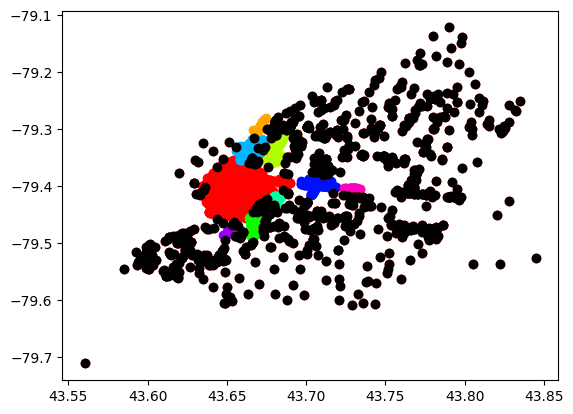

3398
2526


/var/folders/d_/l54g6k2j0jl9bmgzgvfwmbyh0000gp/T/ipykernel_73270/1327053463.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pontos  = [[row[0],row[1]] for index, row in df_high_filtered.iterrows()]


In [98]:
dbscan_config_high = DBSCAN(eps=0.5 /kms_por_radian, min_samples=20, metric="haversine")
dbscan_results_high = dbscan_config_high.fit(np.radians(df_high))


labels_high = dbscan_results_high.labels_
unique_labels_high = list(set(labels_high.tolist()))

cmap = plt.get_cmap('hsv',len(unique_labels_high))

for label in unique_labels_high:
    plt.scatter(df_high.loc[labels_high == label,'latitude'], df_high.loc[labels_high == label,'longitude'], color=cmap(label))

plt.scatter(df_high.loc[labels_high == -1,'latitude'], df_high.loc[labels_high == -1,'longitude'], c = 'black')   

plt.show()

mapa_high = folium.Map(location=[43.648977, -79.420495])

#-1 são pontos considerados ruídos (noises)
df_high_filtered = df_high[labels_high !=-1]

print(len(df_high))
print(len(df_high_filtered))

pontos  = [[row[0],row[1]] for index, row in df_high_filtered.iterrows()]

HeatMap(pontos).add_to(mapa_high)
mapa_high

Um eps de 0.5 em relação a uma região de uma metrópole, é baixo e um min_samples de 20 em relação ao dataset de 3398 pontos, é alto. Essa combinação resulta em clusters pequenos e densos, o que auxilia na identificação de hotspots de locais com muitos estabelecimentos populares em uma área pequena, eliminando possíveis outliers.

### 4.b - Agrupa estabelecimentos que não são populares

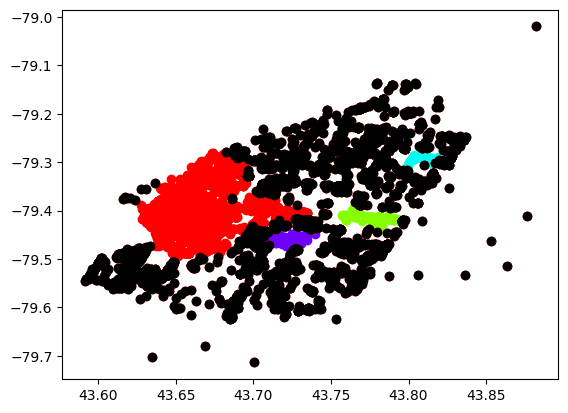

14184
11681


/var/folders/d_/l54g6k2j0jl9bmgzgvfwmbyh0000gp/T/ipykernel_73270/1913051941.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pontos  = [[row[0],row[1]] for index, row in df_low_filtered.iterrows()]


In [119]:
dbscan_config_low = DBSCAN(eps=1 /kms_por_radian, min_samples=100, metric="haversine")
dbscan_results_low = dbscan_config_low.fit(np.radians(df_low))


labels_low = dbscan_results_low.labels_
unique_labels_low = list(set(labels_low.tolist()))

cmap = plt.get_cmap('hsv',len(unique_labels_low))

for label in unique_labels_low:
    plt.scatter(df_low.loc[labels_low == label,'latitude'], df_low.loc[labels_low == label,'longitude'], color=cmap(label))

plt.scatter(df_low.loc[labels_low == -1,'latitude'], df_low.loc[labels_low == -1,'longitude'], c = 'black')   

plt.show()

mapa_low = folium.Map(location=[43.648977, -79.420495])

#-1 são pontos considerados ruídos (noises)
df_low_filtered = df_low[labels_low !=-1]

print(len(df_low))
print(len(df_low_filtered))

pontos  = [[row[0],row[1]] for index, row in df_low_filtered.iterrows()]

HeatMap(pontos).add_to(mapa_low)
mapa_low

Um eps de 1km em relação a região analisada é baixo e o min_samples de 100 em relação aos 14184 é baixo, o que gera muitos clusters pequenos e pouco densos. O valor min_samples de 100, apesar de baixo em relação ao dataset, está limitado pelo espaço físico necessário para estabelecimentos comerciais no raio definido, portanto, não pode ser maior.

## 4.c - Comparação
Os dois resultados mostram que existe uma concentração de estabelecimentos populares e não populares na região sul da cidade. Porém, existem alguns clusters de estabelecimentos não populares em locais em que não se observa um cluster popular. Conclui-se que estabelecimentos não populares são estão mais dispersos na cidade e, apesar de que em locais com muitos estabelecimentos populares também existem muitos estabelecimentos não populares, existem locais em que existem muitos estabelecimentos não populares e poucos populares.